#### Author: Joseph Forson 

## Sentiment Analysis on US Airline Tweets - proj

Train on human labeled US Airline Tweets tweets (14k). 
First use classical meth'd TD-IDF + logistic regresion for this
sentiment project. Should predict if a tweet have a positive, neutral and negative tone.



We report macro-F1 not accuracy because the classes are very imbalanced.

### Preview data

The tweet `text` its `sentiment` label, and the `airline`.

In [40]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

df = pd.read_csv("Tweets.csv")[["text", "airline_sentiment", "airline"]]
df = df.rename(columns={"airline_sentiment": "sentiment"})
print("rows, cols:", df.shape)
df.head()

rows, cols: (14640, 3)


,text,sentiment,airline
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America
1,@VirginAmerica plus you've added commercials to the experience... tacky.,positive,Virgin America
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,neutral,Virgin America
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl...",negative,Virgin America
4,@VirginAmerica and it's a really big bad thing about it,negative,Virgin America


## 2. Exploration

To check imbalance.

sentiment
negative    9178
neutral     3099
positive    2363


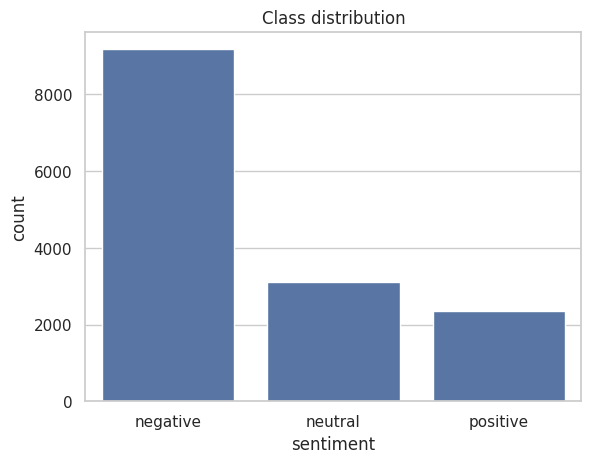

In [ ]:
counts = df["sentiment"].value_counts()
print(counts.to_string())

sns.countplot(data=df, x="sentiment", order=["negative", "neutral", "positive"])
plt.title("Class distribution"); plt.show()

Theres imbalance.

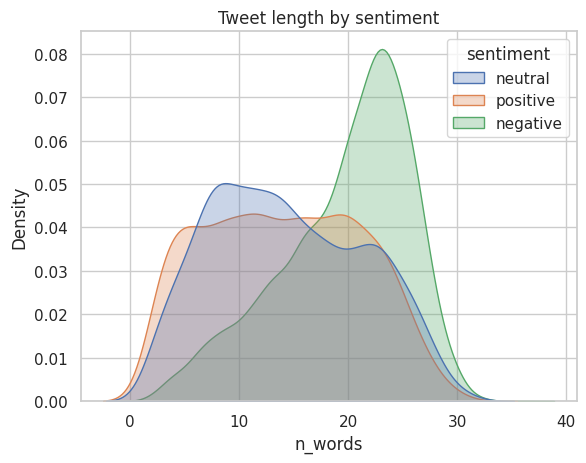

sentiment
negative    21.0
neutral     14.0
positive    14.0
Name: n_words, dtype: float64

In [ ]:
# Do tweet lengths differ by sentiment?
df["n_words"] = df["text"].str.split().apply(len)
sns.kdeplot(data=df, x="n_words", hue="sentiment", common_norm=False, fill=True, alpha=.3)
plt.title("Tweet length by sentiment"); plt.show()
df.groupby("sentiment")["n_words"].median()

Which words dominate each class? <br>
A quick frequency count (stopwords removed).

In [43]:
from sklearn.feature_extraction.text import CountVectorizer

def top_terms(texts, n=10):
    cv = CountVectorizer(stop_words="english", max_features=3000)
    X = cv.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(cv.get_feature_names_out())
    return vocab[freqs.argsort()[::-1][:n]]

for s in ["negative", "neutral", "positive"]:
    print(f"{s:9}:", ", ".join(top_terms(df[df.sentiment == s].text)))

negative : flight, united, usairways, americanair, southwestair, jetblue, cancelled, service, hours, just
neutral  : jetblue, united, southwestair, flight, http, americanair, usairways, virginamerica, just, help
positive : thanks, jetblue, southwestair, united, thank, flight, americanair, usairways, great, http


## 3. Clean the tweet text

Remove noise like @mentions, links, hashtags ...  but keep
apostrophes so words like *don't* / *can't* can  survive.

In [6]:
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # drop links
    text = re.sub(r"@\w+", " ", text)                # drop @mentions
    text = re.sub(r"#", "", text)                     # keep the hashtag word, drop the '#'
    text = re.sub(r"[^a-z\s']", " ", text)           # keep letters + apostrophes only
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean"] = df["text"].apply(clean_tweet)
df[["text", "clean"]].head()

,text,clean
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials to the experience... tacky.,plus you've added commercials to the experience tacky
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,i didn't today must mean i need to take another trip
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl...",it's really aggressive to blast obnoxious entertainment in your guests' faces amp they have little recourse
4,@VirginAmerica and it's a really big bad thing about it,and it's a really big bad thing about it


Encode the labels and make a **stratified** train/test split 

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean"], df["sentiment"],
    test_size=0.2, random_state=42, stratify=df["sentiment"],
)
print(len(X_train), "train /", len(X_test), "test")

11712 train / 2928 test


## TF-IDF + Logistic Regression

- TF-IDF turns each tweet into a vector of word.
- Logistic Regression is  linear classifier.


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, stop_words="english")),
    ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced")),
])
baseline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

Evaluate with the full per-class report + a confusion matrix.

              precision    recall  f1-score   support

    negative      0.881     0.803     0.840      1835
     neutral      0.539     0.685     0.604       620
    positive      0.689     0.679     0.684       473

    accuracy                          0.758      2928
   macro avg      0.703     0.722     0.709      2928
weighted avg      0.777     0.758     0.765      2928

macro-F1: 0.709


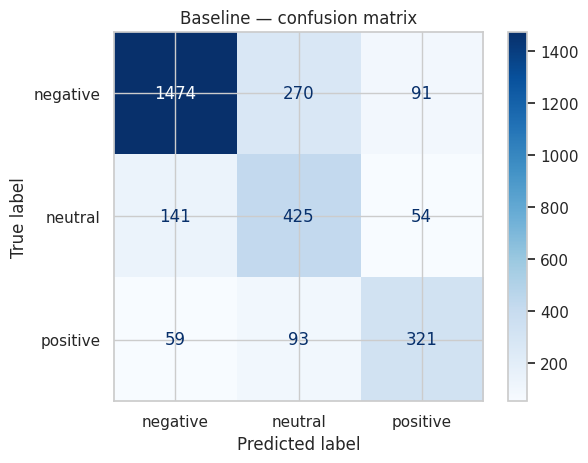

In [9]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, ConfusionMatrixDisplay)

labels = ["negative", "neutral", "positive"]
pred = baseline.predict(X_test)

print(classification_report(y_test, pred, target_names=labels, digits=3))
print("macro-F1:", round(f1_score(y_test, pred, average="macro"), 3))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred, labels=labels), display_labels=labels
).plot(cmap="Blues", values_format="d")
plt.title("Baseline — confusion matrix"); plt.show()

Negative tweets are caught well.
A  sanity check that it learned something sensible.

In [10]:
tfidf = baseline.named_steps["tfidf"]
clf   = baseline.named_steps["clf"]
vocab = np.array(tfidf.get_feature_names_out())

for i, lab in enumerate(clf.classes_):
    top = clf.coef_[i].argsort()[::-1][:10]
    print(f"{lab:9}:", ", ".join(vocab[top]))

negative : hours, delayed, hold, worst, hour, hrs, bag, told, cancelled, customers
neutral  : hi, chance, dm, need, destinationdragons, avgeek, vegas, does, possible, march
positive : great, thank, thanks, awesome, love, best, amazing, thx, appreciate, kudos


## 5. What it gets wrong

After personally reading, I saw it fails in places of ambiguity and context switching. Also some tweets were not labeled well.

In [ ]:
test_df = pd.DataFrame({
    "text": df.loc[X_test.index, "text"].values,
    "true": y_test.values,
    "pred": pred,
})
wrong = test_df[test_df.true != test_df.pred]
print(f"{len(wrong)} of {len(test_df)} misclassified ({len(wrong)/len(test_df):.0%})\n")
pd.set_option("display.max_colwidth", None)
wrong.sample(8, random_state=0)

708 of 2928 misclassified (24%)



,text,true,pred
1358,@SouthwestAir how can customers get in touch with you internationally from Mexico for lost baggage,neutral,negative
1851,@SouthwestAir you know what'd be beyond awesome? A pair of tickets to the @Imaginedragons show in ATL. A girl can dream #DestinationDragons,positive,neutral
791,@united can't wait!!! 787!!! @tpallini http://t.co/oDlall5eDH,positive,negative
1455,@USAirways This flight was for my brother. He has been rebooked and I was able to give my info over the phone to get him a pass to the Club.,negative,neutral
2404,“@united: Looking for a reason to travel? #quote http://t.co/GGuIg3t28z”,positive,neutral
536,"@AmericanAir yes it is in Dulles and I need it delivered to the Embassy Suites in Herndon, VA. I'm still in Chicago from the fiasco in LAX",negative,neutral
1902,@united - Thanks. Formed submitted. I'm not betting someone would be honest enough to turn it in though...,negative,neutral
1885,@USAirways I just checked in online for tomorrow's flight - thought I should get auto upgrade? (Already got the email saying no seats),neutral,negative


## 6. Try some tweets

In [31]:
def predict_sentiment(text):
    return baseline.predict([clean_tweet(text)])[0]

examples = [
    "@united lost my bag AGAIN and nobody will help. worst airline ever.",
    "Thanks @SouthwestAir, crew was lovely and we landed 20 min early!",
    "I am extremely disappointed with the battery life on this new device.",
    "@AmericanAir what time does boarding start for flight 1423?",
    "oh great, another 3 hour delay. just what I wanted.",   # sarcasm — hard case
]
for t in examples:
    print(f"[{predict_sentiment(t):8}]  {t}")

[negative]  @united lost my bag AGAIN and nobody will help. worst airline ever.
[positive]  Thanks @SouthwestAir, crew was lovely and we landed 20 min early!
[negative]  I am extremely disappointed with the battery life on this new device.
[neutral ]  @AmericanAir what time does boarding start for flight 1423?
[positive]  oh great, another 3 hour delay. just what I wanted.
